In [30]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
df = pd.read_csv("ad_spend.csv")
print(df.shape)
df.head()

(200, 3)


,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297
2,328,Monsoon,214
3,322,Monsoon,48
4,726,Winter,1048


In [3]:
g = df.groupby("Season")[["Ad Spend ($)","Revenue ($)"]].mean()
g

,Ad Spend ($),Revenue ($)
Season,,
Monsoon,517.643836,423.150685
Summer,573.836066,689.360656
Winter,552.560606,826.530303


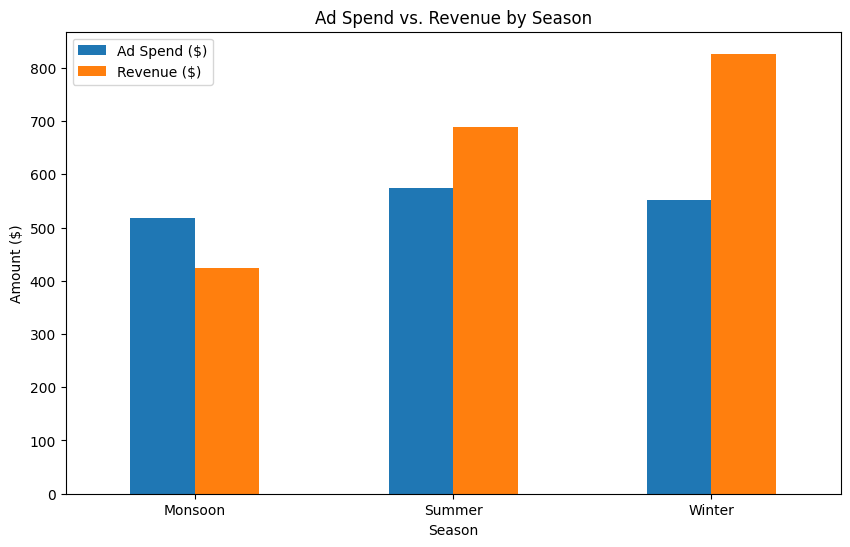

In [12]:
# Just use the .plot() method directly on your DataFrame g
g.plot(kind='bar', figsize=(10, 6))
plt.title('Ad Spend vs. Revenue by Season')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0) # Keeps the season names horizontal
plt.show()

In [14]:
df_encoded = pd.get_dummies(df, columns=["Season"], drop_first=True)
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [20]:
X = df_encoded.drop("Revenue ($)", axis=1)
y = df_encoded["Revenue ($)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [24]:
model.score(X_test, y_test)

0.8882097000477288

In [26]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [27]:
model.score(X_test, y_test)

0.8972778553142061

In [32]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

GradientBoostingRegressor()

In [33]:
model.score(X_test, y_test)

0.9149899654766234

In [35]:
y_pred = model.predict(X_test)

df_eval = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df_eval.head()

,Actual,Predicted
59,605,677.144222
5,1125,1073.575312
20,699,626.698237
198,504,418.202801
52,1310,1134.088133
